In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
# Input data files are available in the /read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip install --upgrade protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 6.33.2 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.2 which is incompatible.
bigframes 2.26.0 requires ri

In [3]:
from PIL import Image 
import itertools 

from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix , classification_report 

import tensorflow as tf
from tensorflow import keras 
from keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout , BatchNormalization
import warnings
warnings.filterwarnings("ignore")

2026-01-07 22:38:02.117636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767825482.305366      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767825482.357012      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767825482.810238      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767825482.810289      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767825482.810292      24 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
folder = '/kaggle/input/brain-tumor-mri-dataset/Training'
path = []
label = []

folders = os.listdir(folder)
for Label in folders :
    folder_path= os.path.join(folder , Label)
    folder_name = os.listdir(folder_path)
    
    for img in folder_name :
        paths = os.path.join(folder_path , img)

        path.append(paths)
        label.append(Label)

In [5]:
Path = pd.Series(path , name='Image_Path')
Label = pd.Series(label , name='Image_Label')
df_train = pd.concat([Path, Label] , axis=1)

In [6]:
df_train

,Image_Path,Image_Label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [7]:
df_train['Image_Label'].unique()

array(['pituitary', 'notumor', 'meningioma', 'glioma'], dtype=object)

In [8]:
folder = '/kaggle/input/brain-tumor-mri-dataset/Testing'
path = []
label = []

folders = os.listdir(folder)
for Label in folders :
    folder_path= os.path.join(folder , Label)
    folder_name = os.listdir(folder_path)
    
    for img in folder_name :
        paths = os.path.join(folder_path , img)

        path.append(paths)
        label.append(Label)

In [9]:
Path = pd.Series(path , name='Image_Path')
Label = pd.Series(label , name='Image_Label')
df_test = pd.concat([Path, Label] , axis=1)

In [10]:
df_test

,Image_Path,Image_Label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1306,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1307,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1308,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1309,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


In [11]:
df_vaild , df_test = train_test_split(df_test , shuffle=True , train_size=0.5 , random_state=42)

In [12]:
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

df_tr = tr_gen.flow_from_dataframe(
    df_train, 
    x_col='Image_Path',  
    y_col='Image_Label', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

df_va = ts_gen.flow_from_dataframe(
    df_vaild , 
    x_col='Image_Path',  
    y_col='Image_Label', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

df_te = ts_gen.flow_from_dataframe(
    df_test, 
    x_col='Image_Path',  
    y_col='Image_Label', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=False, 
    batch_size=batch_size
)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


In [13]:
img_shape = (224,244,3)


model = Sequential([
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(256,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(4, activation = "softmax")
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

I0000 00:00:1767825510.053949      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767825510.054685      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 244, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 244, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 122, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 122, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 122, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 61, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 61, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 61, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 61, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 30, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,154,180 (80.70 MB)

 Trainable params: 21,154,180 (80.70 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(df_tr, epochs= 12, verbose= 1, validation_data= df_va, shuffle= False)

Epoch 1/12


I0000 00:00:1767825515.288711      74 service.cc:152] XLA service 0x7edb8800cdb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767825515.288749      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767825515.288756      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767825516.006501      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-07 22:38:45.940492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 22:38:46.123224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 22:38:47.130952: E external/local_xl

357/357 ━━━━━━━━━━━━━━━━━━━━ 141s 322ms/step - accuracy: 0.5062 - loss: 12.4858 - val_accuracy: 0.7084 - val_loss: 0.6914
Epoch 2/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 102s 285ms/step - accuracy: 0.8009 - loss: 0.5213 - val_accuracy: 0.8076 - val_loss: 0.4616
Epoch 3/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 102s 285ms/step - accuracy: 0.8551 - loss: 0.3758 - val_accuracy: 0.8397 - val_loss: 0.4375
Epoch 4/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 102s 287ms/step - accuracy: 0.8897 - loss: 0.2790 - val_accuracy: 0.8412 - val_loss: 0.4101
Epoch 5/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 102s 287ms/step - accuracy: 0.9150 - loss: 0.2269 - val_accuracy: 0.9130 - val_loss: 0.2227
Epoch 6/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 287ms/step - accuracy: 0.9374 - loss: 0.1755 - val_accuracy: 0.8992 - val_loss: 0.2772
Epoch 7/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 287ms/step - accuracy: 0.9522 - loss: 0.1387 - val_accuracy: 0.8580 - val_loss: 0.3357
Epoch 8/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 102s 286ms/step - accuracy: 0.9547 - loss: 0.1

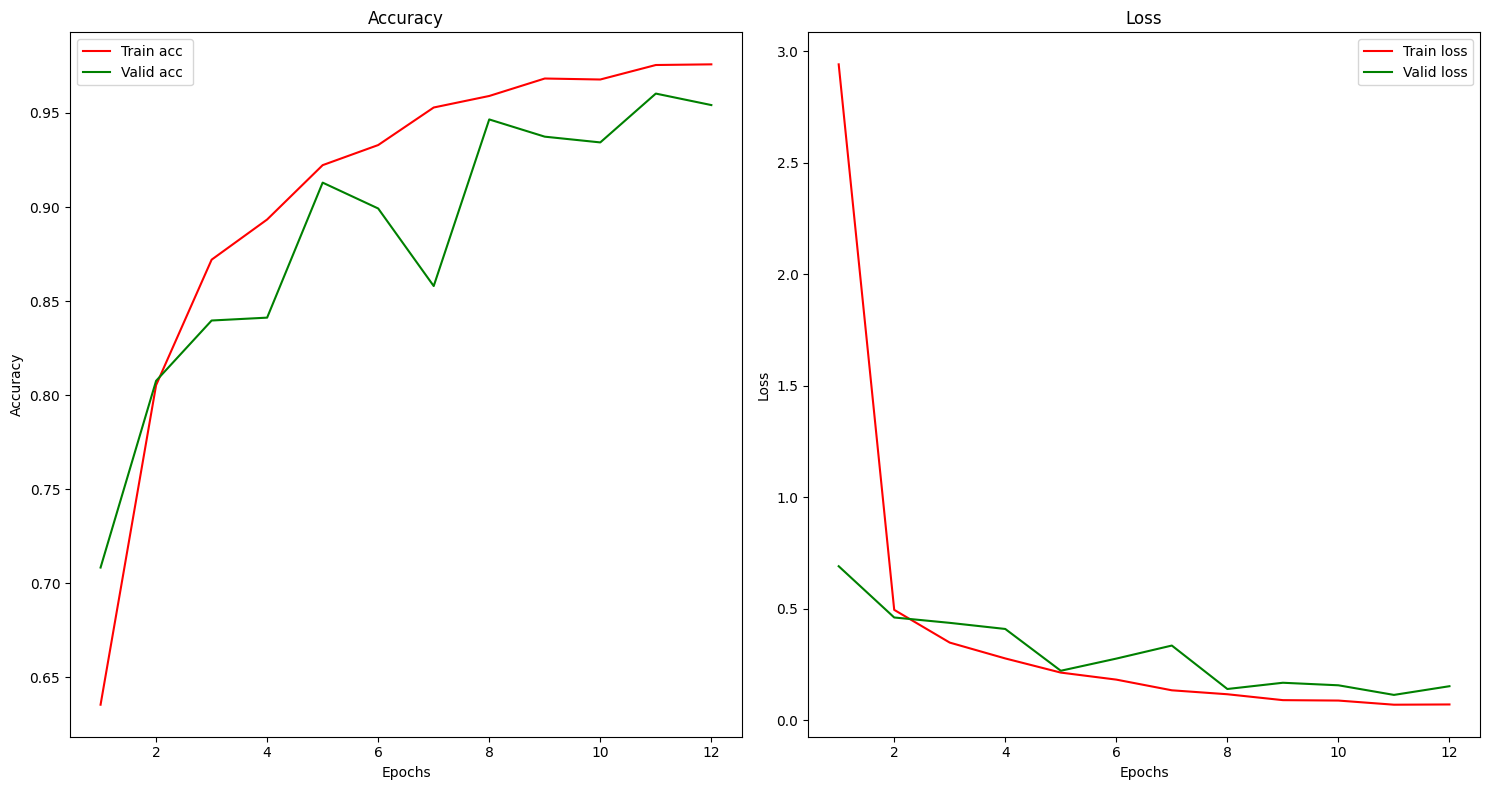

In [15]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.plot(epochs, tr_acc , 'r' , label='Train acc')
plt.plot(epochs , val_acc , 'g' , label='Valid acc ')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs , tr_loss , 'r' , label='Train loss')
plt.plot(epochs , val_loss , 'g' , label='Valid loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
tr_score = model.evaluate(df_tr , verbose=1)
te_score = model.evaluate(df_te , verbose=1)
va_score = model.evaluate(df_va , verbose=1)

print(' train_score : ' , tr_score)
print(' test_score  : ' , te_score)
print(' valid_score : ' , va_score)

357/357 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.9839 - loss: 0.0423
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9238 - loss: 0.2917
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9542 - loss: 0.1475
 train_score :  [0.04343297332525253, 0.9838935732841492]
 test_score  :  [0.22877711057662964, 0.9375]
 valid_score :  [0.1534041315317154, 0.9541984796524048]


In [17]:
predict = model.predict(df_te)
y_pred = np.argmax(predict , axis=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step


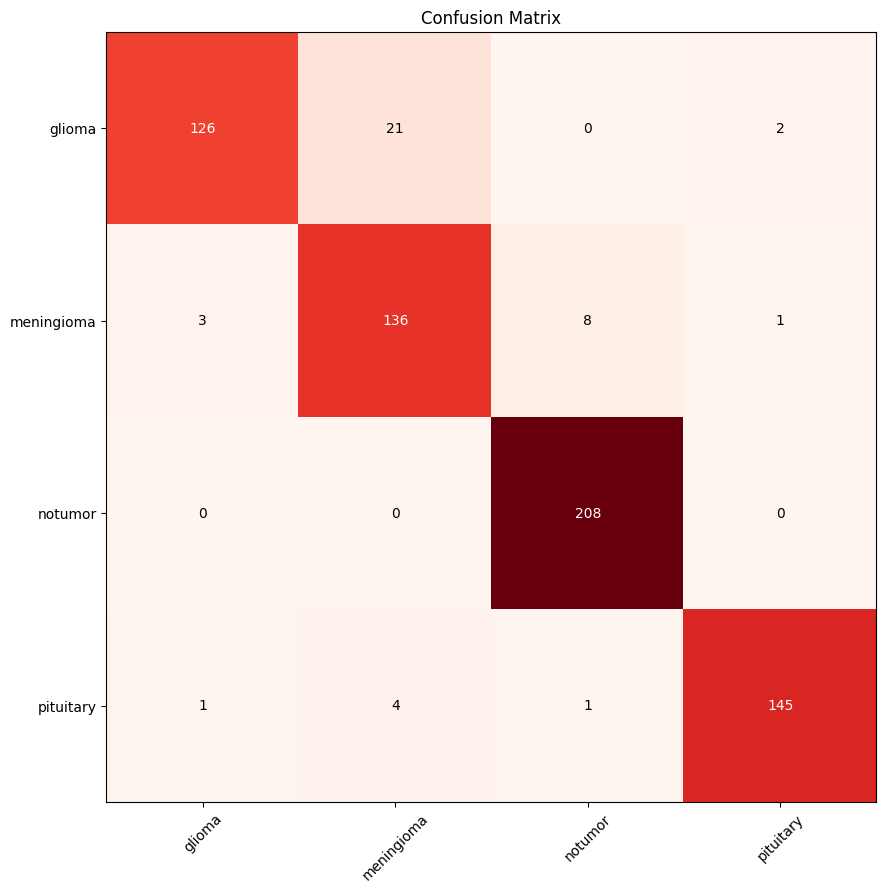

In [18]:
g_dict = df_te.class_indices
classes = list(g_dict.keys())


cm = confusion_matrix(df_te.classes, y_pred)

plt.figure(figsize=(10, 10))
plt.title('Confusion Matrix')
plt.imshow(cm, interpolation='nearest', cmap='Reds')  

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j],
                 ha='center', va='center',
                 color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.show()

In [19]:
print(classification_report(df_te.classes, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90       149
           1       0.84      0.92      0.88       148
           2       0.96      1.00      0.98       208
           3       0.98      0.96      0.97       151

    accuracy                           0.94       656
   macro avg       0.94      0.93      0.93       656
weighted avg       0.94      0.94      0.94       656



In [20]:
model.save('Brain Classifier.h5')